# Second model (goal=0.127992 (top 1000))
im impementing pipelines and XGboost on this model

## Equal to model 1 (load train set)

In [210]:
# Librerías para manipulación de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from random import randint
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
# Configuración para que se muestren bien los gráficos
%matplotlib inline
print("Librerías importadas correctamente.")




Librerías importadas correctamente.


In [211]:
 # Cargar los datos
df = pd.read_csv('../data/train.csv', index_col='Id')

# Mostrar las primeras 5 filas para confirmar la carga
print("Fisrt 5 rows:")
df.head()

Fisrt 5 rows:


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [212]:
df_to_pred = pd.read_csv('../data/test.csv', index_col='Id')
df_to_pred_num=df_to_pred.select_dtypes(include=['float64', 'int64'])
df_to_pred_cat=df_to_pred.select_dtypes(exclude=['float64', 'int64'])
df_to_pred

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml


In [213]:
#hago un dataframe numerico
dfNum=df.select_dtypes(include=['float64', 'int64'])
#extraigo las columnas que no son numéricas
dfCat = df.select_dtypes(exclude=['float64', 'int64'])
Categoric=dfCat.columns.tolist()


## Starting simple

making a corr matrix

In [214]:
zeromeanslack=['GarageArea', 'TotalBsmtSF', 'MasVnrArea', 'BsmtFinSF1', 'WoodDeckSF','2ndFlrSF', 'OpenPorchSF', 'BsmtUnfSF', 'EnclosedPorch','ScreenPorch','PoolArea','3SsnPorch','LowQualFinSF','MiscVal','BsmtFinSF2']

#corrmatrix
corr_matrix= dfNum.corr()['SalePrice'].drop('SalePrice')

#calc corr with saleprice for each feature independently (THIS ACTUUALLY IS NOT THAT USEFULL XD)
for column in zeromeanslack:
    corr_matrix[column]=dfNum[dfNum[column]!=0].corr()['SalePrice'][column]
corr_matrix.sort_values(ascending=False)
display(corr_matrix)
numeric_nms__bsd_on_corr=corr_matrix.index


MSSubClass      -0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond     -0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.434090
BsmtFinSF1       0.471690
BsmtFinSF2       0.198956
BsmtUnfSF        0.169261
TotalBsmtSF      0.609681
1stFlrSF         0.605852
2ndFlrSF         0.673305
LowQualFinSF     0.300075
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath    -0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.608405
WoodDeckSF       0.193706
OpenPorchSF      0.086453
EnclosedPorch    0.241279
3SsnPorch        0.063932
ScreenPorch      0.255430
PoolArea        -0.014092
MiscVal          0.088963
MoSold           0.046432
YrSold          -0.028923
Name: SalePrice, dtype: float64

In [215]:
cat_nms_bsd_previus=['Neighborhood','MasVnrType','ExterQual','BsmtQual','HeatingQC','KitchenQual','GarageFinish']

In [216]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [217]:
num_pipeline

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])

In [218]:
cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [219]:
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, numeric_nms__bsd_on_corr),
    ("cat", cat_pipeline, cat_nms_bsd_previus)
])

In [220]:
from sklearn.ensemble import RandomForestRegressor

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

In [221]:
fisrtpipelinedf=df.copy()
fisrtpipelineydf=fisrtpipelinedf['SalePrice']
fisrtpipelinedf=fisrtpipelinedf.drop('SalePrice',axis=1)

x_train, x_test, y_train, y_test = train_test_split(fisrtpipelinedf,fisrtpipelineydf, test_size=0.2, random_state=67)

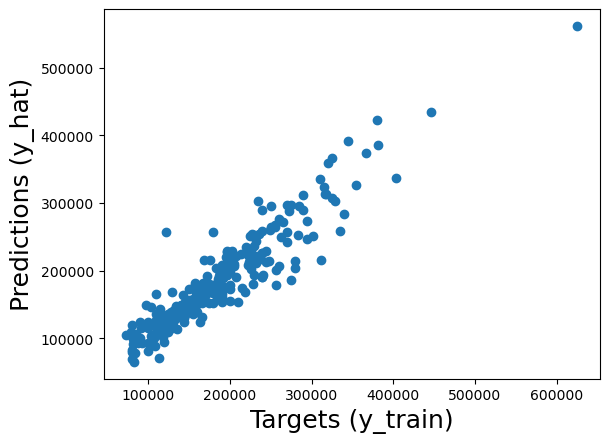

In [222]:
model_pipeline.fit(x_train, y_train)
y_pred = model_pipeline.predict(x_test)
plt.scatter(y_test,y_pred)
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (y_hat)',size=18)
plt.show()

In [223]:
def createsubmissionfie(name,model,x_to_pred):
    import joblib
    joblib.dump(model, f'Model_{name}.joblib')


    pred_test=model.predict(x_to_pred)
    submission = pd.DataFrame({
        'Id': x_to_pred.index,
        'SalePrice': pred_test
    })

    # Guardar el archivo
    submission.to_csv(f'Submission_{name}.csv', index=False)
    print("Archivo de submission creado exitosamente!")

In [224]:
def getscore(test,hat):
    hat = np.maximum(hat, 0)
    test = np.maximum(test, 0)

    rmsle = np.sqrt(mean_squared_log_error(test, hat))
    return rmsle

In [225]:
getscore(y_test,y_pred)

np.float64(0.13975757741549857)

In [226]:
createsubmissionfie('2_1',model_pipeline,df_to_pred)

Archivo de submission creado exitosamente!


Ths got .147976, so is my best and also was super easy, so that i feel weird

In [227]:
from xgboost import XGBRegressor

In [228]:
model_pipelineXGBoost = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        tree_method="hist"   # opcional, más rápido
    ))
])


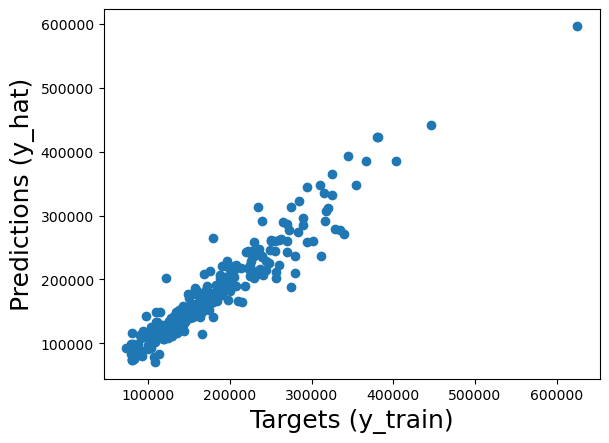

In [229]:
model_pipelineXGBoost.fit(x_train, y_train)
y_pred = model_pipelineXGBoost.predict(x_test)
plt.scatter(y_test,y_pred)
plt.xlabel('Targets (y_train)',size=18)
plt.ylabel('Predictions (y_hat)',size=18)
plt.show()

In [230]:
getscore(y_test,y_pred)

np.float64(0.1195358537273578)

In [231]:
createsubmissionfie('2_2',model_pipelineXGBoost,df_to_pred)

Archivo de submission creado exitosamente!


In [361]:

def modelmaker(df,y,rnd="na"):
    formodeldf=df.copy()
    
    if rnd=="na":
        rnd=randint(1,500)

    x_train, x_test, y_train, y_test = train_test_split(formodeldf,y, test_size=0.2, random_state=rnd)


    reg=LinearRegression()
    reg.fit(x_train,y_train)
    y_hat=reg.predict(x_test)
    
    # scores=pd.DataFrame(data={'Medida':["MAE","MSE","RMSE","R2"],'Valor':[mae,mse,rmse,r2]})
    # scores.style.format({'Valor': '{:.2f}'})

    #get rid of 0's for RMSLE
    y_pred_no0 = np.maximum(y_hat, 0)
    y_test_no0 = np.maximum(y_test, 0)

    rmsle = np.sqrt(mean_squared_log_error(y_test_no0, y_pred_no0))
    #mod is for returning the model intead of metrics


    return rmsle, reg


In [362]:
father_df=df.copy()
nonadf=father_df.copy()
nonadf[dfNum.columns] = nonadf[dfNum.columns].fillna(nonadf[dfNum.columns].median())
nonadf

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500


In [363]:
dummies = pd.get_dummies(nonadf, drop_first=True,)
dummies

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,False,False,False,False,True,False,False,False,True,False
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,False,False,False,False,True,False,False,False,True,False
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,False,False,False,False,True,False,False,False,True,False
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,False,False,False,False,True,False,False,False,False,False
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,False,False,False,False,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,False,False,False,False,True,False,False,False,True,False
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,False,False,False,False,True,False,False,False,True,False
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,False,False,False,False,True,False,False,False,True,False


In [365]:
def addhascolumns(df,columnames):
    dfforfunc=df.copy()
    for column in columnames:
        if column in dfforfunc.columns:
            #for each column to clean if is in the df, create a has feature with 0 if 0 and 1 if >0
            dfforfunc[f'has {column}']=(dfforfunc[column]>0).astype(int)
        else:
            print(f"{column} wasn't found")
    return dfforfunc

In [366]:
dfformegamodel=addhascolumns(dummies,zeromeanslack)
dfformegamodel

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,has 2ndFlrSF,has OpenPorchSF,has BsmtUnfSF,has EnclosedPorch,has ScreenPorch,has PoolArea,has 3SsnPorch,has LowQualFinSF,has MiscVal,has BsmtFinSF2
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,1,1,1,0,0,0,0,0,0,0
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,0,0,1,0,0,0,0,0,0,0
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,1,1,1,0,0,0,0,0,0,0
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,1,1,1,1,0,0,0,0,0,0
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,1,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,1,1,1,0,0,0,0,0,0,0
1457,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,0,0,1,0,0,0,0,0,0,1
1458,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,1,1,1,0,0,0,0,0,1,0


In [367]:
yformegamodel=dfformegamodel['SalePrice']
dfformegamodel=dfformegamodel.drop('SalePrice', axis=1)


In [368]:
supermodel=modelmaker(dfformegamodel,yformegamodel,42)[1]

In [369]:
df_to_pred['SalePrice']=0
df_to_pred[dfNum.columns] = df_to_pred[dfNum.columns].fillna(df_to_pred[dfNum.columns].median())


x_predformegamodel=pd.get_dummies(df_to_pred, drop_first=True,)
x_predformegamodel.drop('SalePrice', axis=1)
x_predformegamodel=addhascolumns(x_predformegamodel,zeromeanslack)

x_predformegamodel

unseenidkwhy=list(set(dfformegamodel.columns) - set(x_predformegamodel.columns))

x_predformegamodel[unseenidkwhy]=0

x_predformegamodel = x_predformegamodel[dfformegamodel.columns]



In [370]:
def createsubmissionfie(name,model,x_to_pred):


    import joblib
    joblib.dump(model, f'Model_{name}.joblib')


    pred_test=model.predict(x_to_pred)
    submission = pd.DataFrame({
        'Id': x_to_pred.index,
        'SalePrice': pred_test
    })

    # Guardar el archivo
    submission.to_csv(f'Submission_{name}.csv', index=False)
    print("Archivo de submission creado exitosamente!")

In [371]:
createsubmissionfie("1_9",supermodel,x_predformegamodel)

Archivo de submission creado exitosamente!


so this was quite rustic so, now im going to select some specific variables fo de dummies, adn use my previus best model 

firts im getting a correlation matrix with saleprice

From categorical vars i selected some that semeed to provide more variance

In [373]:
selectctfd=dfCat.copy()

selectctfd['SalePrice']=dfNum['SalePrice']

selectctfd = selectctfd[selectctfd['SalePrice'] < selectctfd['SalePrice'].quantile(0.95)]


In [374]:
# cat_per_column=pd.DataFrame()
# for colum in selectctfd.drop('SalePrice',axis=1).columns:
#     i=0
#     sscolumn=pd.Series()
#     for cat in selectctfd[colum].unique():
#         sscolumn[i]=selectctfd[selectctfd[colum]==cat]['SalePrice'].median()
#         i+=1
#     cat_per_column = pd.concat([cat_per_column, sscolumn.rename(colum)], axis=1)
cat_per_column=pd.DataFrame()
ns_per_column=pd.DataFrame()
for colum in selectctfd.drop('SalePrice',axis=1).columns:
    i=0
    sscolumn=pd.Series()
    
    nanns=selectctfd[colum].isna().sum()
    if nanns:
        restserie=np.append(selectctfd[colum].value_counts().values,nanns)
        restserie=pd.Series(restserie)
    else:
        restserie=selectctfd[colum].value_counts().values
        restserie=pd.Series(restserie)

    for cat in selectctfd[colum].unique():
        sscolumn[i]=selectctfd[selectctfd[colum]==cat]['SalePrice'].median()
        i+=1
    cat_per_column = pd.concat([cat_per_column, sscolumn.rename(colum)], axis=1)
    ns_per_column = pd.concat([ns_per_column, restserie.rename(colum)], axis=1)

In [375]:
cat_per_column.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,169945.0,159000.0,NaN,144500.0,158000.0,159000.0,155000.0,158000.0,195950.0,161750.0,...,180000.0,187500.0,165000.0,165000.0,164000.0,NaN,NaN,NaN,155000.0,157500.0
1,120250.0,114250.0,119500.0,184000.0,139400.0,137500.0,164000.0,170000.0,206000.0,140000.0,...,129500.0,135000.0,115000.0,114504.0,111000.0,235000.0,137000.0,144000.0,220750.0,130000.0
2,74700.0,NaN,172500.0,195000.0,188700.0,NaN,158500.0,182500.0,191000.0,198750.0,...,108000.0,194201.0,209115.0,NaN,132250.0,215500.0,138500.0,170750.0,139000.0,220000.0
3,197000.0,NaN,NaN,192140.0,188750.0,NaN,191000.0,NaN,270395.0,119200.0,...,214950.0,NaN,NaN,148000.0,NaN,171000.0,166250.0,94000.0,140000.0,104000.0
4,136500.0,NaN,NaN,NaN,NaN,NaN,195450.0,NaN,153500.0,142500.0,...,NaN,NaN,96500.0,108000.0,NaN,NaN,130000.0,250000.0,120000.0,142953.0


In [376]:
minusmean=cat_per_column-cat_per_column.mean()
catordered=minusmean.abs().sum().sort_values(ascending=False)
catordered

Neighborhood         1061067.2
Exterior1st           626040.0
Exterior2nd          503459.25
Condition2           404696.25
RoofMatl              350375.0
SaleType         330744.444444
ExterQual             281200.0
Condition1            230380.0
BsmtQual              217225.0
KitchenQual           213745.0
MiscFeature           182750.0
GarageQual            180538.0
HouseStyle            179865.0
Heating               176675.0
MSZoning              175174.0
FireplaceQu           174800.0
GarageType            169950.0
ExterCond             169300.0
BsmtCond              168500.0
SaleCondition    158364.666667
Foundation       147833.333333
Electrical            142200.0
HeatingQC             131840.0
RoofStyle             128300.0
Functional       103214.285714
BsmtFinType1     101633.333333
GarageCond             98396.8
BsmtFinType2           94100.0
MasVnrType             90000.0
LotConfig              81740.0
BldgType               80796.0
LandContour            80050.0
GarageFi

In [377]:
ns_per_column

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,1084.0,1381.0,50.0,893.0,1249.0,1386.0,1001.0,1316.0,224,1191.0,...,815.0,602.0,1239.0,1253.0,1267.0,3.0,155.0,49.0,1228.0,1160.0
1,216.0,6.0,41.0,450.0,63.0,1.0,252.0,59.0,148,81.0,...,386.0,405.0,48.0,35.0,90.0,2.0,58.0,2.0,90.0,99.0
2,61.0,NaN,1296.0,35.0,41.0,NaN,85.0,12.0,112,47.0,...,72.0,299.0,14.0,9.0,30.0,1.0,53.0,2.0,43.0,93.0
3,16.0,NaN,NaN,9.0,34.0,NaN,45.0,NaN,100,25.0,...,18.0,81.0,3.0,7.0,NaN,1381.0,11.0,1.0,9.0,20.0
4,10.0,NaN,NaN,NaN,NaN,NaN,4.0,NaN,81,18.0,...,9.0,NaN,2.0,2.0,NaN,NaN,1110.0,1333.0,5.0,11.0
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,78,11.0,...,6.0,NaN,81.0,81.0,NaN,NaN,NaN,NaN,4.0,4.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74,7.0,...,81.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [378]:
distancemetric=1000/(ns_per_column.pow(2).sum())
distancemetric.sort_values(ascending=False)


Neighborhood     0.007264
Exterior2nd      0.002766
Exterior1st      0.002654
BsmtFinType1     0.002510
GarageFinish     0.001607
FireplaceQu      0.001481
HouseStyle       0.001480
HeatingQC        0.001441
Foundation       0.001327
BsmtQual         0.001278
GarageType       0.001212
KitchenQual      0.001173
MasVnrType       0.001091
BsmtExposure     0.001061
LotShape         0.000999
ExterQual        0.000984
LotConfig        0.000930
MSZoning         0.000816
Fence            0.000792
RoofStyle        0.000774
BldgType         0.000746
SaleCondition    0.000733
BsmtFinType2     0.000707
Condition1       0.000700
ExterCond        0.000669
SaleType         0.000659
GarageQual       0.000648
BsmtCond         0.000645
LandContour      0.000638
GarageCond       0.000634
Electrical       0.000625
PavedDrive       0.000619
Functional       0.000602
CentralAir       0.000596
Alley            0.000594
LandSlope        0.000576
MiscFeature      0.000562
Heating          0.000544
RoofMatl    

In [379]:
ord_bsd_on_median_ns=(catordered*distancemetric).sort_values(ascending=False)
ord_bsd_on_median_ns

Neighborhood     7707.715218
Exterior1st      1661.733986
Exterior2nd      1392.760517
BsmtQual          277.549565
ExterQual         276.802985
HouseStyle        266.112245
FireplaceQu        258.81381
BsmtFinType1      255.145376
KitchenQual       250.749921
SaleType          217.870664
Condition2        214.672813
GarageType        205.898423
Foundation        196.146853
HeatingQC         189.985691
RoofMatl          188.307343
Condition1        161.285467
MSZoning           142.90714
GarageFinish      119.647189
GarageQual        116.913991
SaleCondition     116.053184
ExterCond         113.284232
BsmtCond          108.731915
MiscFeature       102.708988
RoofStyle           99.30502
MasVnrType         98.195708
Heating            96.066272
Electrical         88.891834
LotConfig           76.05341
LotShape           68.733739
BsmtFinType2       66.526732
GarageCond         62.358192
Functional         62.121932
BsmtExposure       60.991076
BldgType           60.280452
LandContour   

In [380]:
numerical_2=dfNum.copy()
y_categorical_selction=numerical_2['SalePrice']
numerical_2=numerical_2.drop(['SalePrice','1stFlrSF', 'YearBuilt', 'GarageYrBlt', 'LotFrontage', 'HalfBath', 'ScreenPorch', 'EnclosedPorch', 'BsmtFullBath', 'OpenPorchSF', '3SsnPorch', 'MoSold', 'PoolArea', 'YrSold', 'KitchenAbvGr'], axis=1)
numerical_2=addhascolumns(numerical_2,zeromeanslack)
numerical_2=numerical_2.fillna(numerical_2.median())
numerical_2

OpenPorchSF wasn't found
EnclosedPorch wasn't found
ScreenPorch wasn't found
PoolArea wasn't found
3SsnPorch wasn't found


,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,has GarageArea,has TotalBsmtSF,has MasVnrArea,has BsmtFinSF1,has WoodDeckSF,has 2ndFlrSF,has BsmtUnfSF,has LowQualFinSF,has MiscVal,has BsmtFinSF2
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,196.0,706,0,150,856,...,1,1,1,1,0,1,1,0,0,0
2,20,9600,6,8,1976,0.0,978,0,284,1262,...,1,1,0,1,1,0,1,0,0,0
3,60,11250,7,5,2002,162.0,486,0,434,920,...,1,1,1,1,0,1,1,0,0,0
4,70,9550,7,5,1970,0.0,216,0,540,756,...,1,1,0,1,0,1,1,0,0,0
5,60,14260,8,5,2000,350.0,655,0,490,1145,...,1,1,1,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,7917,6,5,2000,0.0,0,0,953,953,...,1,1,0,0,0,1,1,0,0,0
1457,20,13175,6,6,1988,119.0,790,163,589,1542,...,1,1,1,1,1,0,1,0,0,1
1458,70,9042,7,9,2006,0.0,275,0,877,1152,...,1,1,0,1,0,1,1,0,1,0


In [381]:
scorenum=[]
for i in range(1,1000):
    scorenum.append(modelmaker(numerical_2,y_categorical_selction,i)[0])

In [382]:
selected_categoricals=dfCat.copy()
selected_categoricals=selected_categoricals[catordered.index[:10]]

In [383]:
selected_cat_df=pd.concat([numerical_2,selected_categoricals], axis=1)
selected_cat_df

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,Neighborhood,Exterior1st,Exterior2nd,Condition2,RoofMatl,SaleType,ExterQual,Condition1,BsmtQual,KitchenQual
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,196.0,706,0,150,856,...,CollgCr,VinylSd,VinylSd,Norm,CompShg,WD,Gd,Norm,Gd,Gd
2,20,9600,6,8,1976,0.0,978,0,284,1262,...,Veenker,MetalSd,MetalSd,Norm,CompShg,WD,TA,Feedr,Gd,TA
3,60,11250,7,5,2002,162.0,486,0,434,920,...,CollgCr,VinylSd,VinylSd,Norm,CompShg,WD,Gd,Norm,Gd,Gd
4,70,9550,7,5,1970,0.0,216,0,540,756,...,Crawfor,Wd Sdng,Wd Shng,Norm,CompShg,WD,TA,Norm,TA,Gd
5,60,14260,8,5,2000,350.0,655,0,490,1145,...,NoRidge,VinylSd,VinylSd,Norm,CompShg,WD,Gd,Norm,Gd,Gd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,7917,6,5,2000,0.0,0,0,953,953,...,Gilbert,VinylSd,VinylSd,Norm,CompShg,WD,TA,Norm,Gd,TA
1457,20,13175,6,6,1988,119.0,790,163,589,1542,...,NWAmes,Plywood,Plywood,Norm,CompShg,WD,TA,Norm,Gd,TA
1458,70,9042,7,9,2006,0.0,275,0,877,1152,...,Crawfor,CemntBd,CmentBd,Norm,CompShg,WD,Ex,Norm,TA,Gd


In [384]:
selected_cat_df=pd.get_dummies(selected_cat_df)

In [385]:

print(modelmaker(selected_cat_df,y_categorical_selction,2))
print(modelmaker(numerical_2,y_categorical_selction,2))
    

(np.float64(0.22132645783967397), LinearRegression())
(np.float64(0.15849173904374095), LinearRegression())


so we lost? to our selves?

who decided that?

In [386]:
scorecat=[]
for i in range(1,1000):
    scorecat.append(modelmaker(selected_cat_df,y_categorical_selction,i)[0])

In [387]:
pd.DataFrame({'scorecat': scorecat, 'scorenum': scorenum}).mean()

scorecat    0.173866
scorenum    0.276621
dtype: float64

it seems klike we did not

In [388]:
x_num=df_to_pred_num.copy()
x_num=x_num.drop(['1stFlrSF', 'YearBuilt', 'GarageYrBlt', 'LotFrontage', 'HalfBath', 'ScreenPorch', 'EnclosedPorch', 'BsmtFullBath', 'OpenPorchSF', '3SsnPorch', 'MoSold', 'PoolArea', 'YrSold', 'KitchenAbvGr'], axis=1)
x_num=addhascolumns(x_num,zeromeanslack)
x_num=x_num.fillna(x_num.median())

x_cat=df_to_pred_cat.copy()
x_cat=x_cat[catordered.index[:10]]

x_final=pd.concat([x_num,x_cat], axis=1)
x_final=pd.get_dummies(x_final)


unseenikwhy=list(set(selected_cat_df.columns) - set(x_final.columns))

x_final[unseenikwhy]=0

x_final = x_final[selected_cat_df.columns]

OpenPorchSF wasn't found
EnclosedPorch wasn't found
ScreenPorch wasn't found
PoolArea wasn't found
3SsnPorch wasn't found


In [389]:
n=randint(1,100)
modelcat=modelmaker(selected_cat_df,y_categorical_selction,n)

In [390]:
print(n,modelcat)
createsubmissionfie("1_10",modelcat[1],x_final)
#67

15 (np.float64(0.15666263068765482), LinearRegression())
Archivo de submission creado exitosamente!


Now im selecting the categorical variables manually, and cleaning outliers for the training

In [391]:
slectedcats=['Neighborhood','MasVnrType','ExterQual','BsmtQual','HeatingQC','KitchenQual','GarageFinish']

In [392]:
refinedcat=dfCat.copy()
refinedcat=refinedcat[slectedcats]


In [393]:
numerical_refined=numerical_2

numerical_refined['SalePrice']=y_categorical_selction
numerical_refined = numerical_refined[numerical_refined['SalePrice'] < numerical_refined['SalePrice'].quantile(0.95)]

In [394]:
refinedcat = refinedcat.loc[numerical_refined.index]


In [395]:
refinedc_x_train=pd.concat([numerical_refined,refinedcat], axis=1)
refinedc_x_train=pd.get_dummies(refinedc_x_train,drop_first=True)
y_refined=refinedc_x_train['SalePrice']
refinedc_x_train=refinedc_x_train.drop('SalePrice',axis=1)
refinedc_x_train

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,BsmtQual_TA,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_RFn,GarageFinish_Unf
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,196.0,706,0,150,856,...,False,False,False,False,False,False,True,False,True,False
2,20,9600,6,8,1976,0.0,978,0,284,1262,...,False,False,False,False,False,False,False,True,True,False
3,60,11250,7,5,2002,162.0,486,0,434,920,...,False,False,False,False,False,False,True,False,True,False
4,70,9550,7,5,1970,0.0,216,0,540,756,...,True,False,True,False,False,False,True,False,False,True
5,60,14260,8,5,2000,350.0,655,0,490,1145,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,7917,6,5,2000,0.0,0,0,953,953,...,False,False,False,False,False,False,False,True,True,False
1457,20,13175,6,6,1988,119.0,790,163,589,1542,...,False,False,False,False,True,False,False,True,False,True
1458,70,9042,7,9,2006,0.0,275,0,877,1152,...,True,False,False,False,False,False,True,False,True,False


In [396]:
refined_pred=df_to_pred_cat.copy()
refined_pred=refined_pred[slectedcats]
refined_pred_num=x_num.copy()

refinedc_x_test=pd.concat([refined_pred_num,refined_pred], axis=1)
refinedc_x_test=pd.get_dummies(refinedc_x_test,drop_first=True)
refinedc_x_test

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,BsmtQual_TA,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,GarageFinish_RFn,GarageFinish_Unf
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,11622,5,6,1961,0.0,468.0,144.0,270.0,882.0,...,True,False,False,False,True,False,False,True,False,True
1462,20,14267,6,6,1958,108.0,923.0,0.0,406.0,1329.0,...,True,False,False,False,True,False,True,False,False,True
1463,60,13830,5,5,1998,0.0,791.0,0.0,137.0,928.0,...,False,False,True,False,False,False,False,True,False,False
1464,60,9978,6,6,1998,20.0,602.0,0.0,324.0,926.0,...,True,False,False,False,False,False,True,False,False,False
1465,120,5005,8,5,1992,0.0,263.0,0.0,1017.0,1280.0,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,1936,4,7,1970,0.0,0.0,0.0,546.0,546.0,...,True,False,True,False,False,False,False,True,False,False
2916,160,1894,4,5,1970,0.0,252.0,0.0,294.0,546.0,...,True,False,False,False,True,False,False,True,False,True
2917,20,20000,5,7,1996,0.0,1224.0,0.0,0.0,1224.0,...,True,False,False,False,False,False,False,True,False,True


In [397]:
refined_model=modelmaker(refinedc_x_train,y_refined,67)

In [398]:
createsubmissionfie("1_11",refined_model[1],refinedc_x_test)

Archivo de submission creado exitosamente!


this model got .1535

In [399]:
refinedmodels=[]
for i in range (0,1000):
    refinedmodels.append(modelmaker(refinedc_x_train,y_refined,i)[0])


In [400]:
idx=pd.DataFrame(refinedmodels).idxmin()[0]
idx

np.int64(738)

In [401]:
best=modelmaker(refinedc_x_train,y_refined,idx)
best[0]


np.float64(0.1133780029061371)

In [402]:
createsubmissionfie("1_12",best[1],refinedc_x_test)

Archivo de submission creado exitosamente!


this one got .1585

this is the end of experiments 2, now i will rok on EDA2 and Model 2 wich will use XGBoost

before that i made a new order for my categorical variables, so im training many models based on that order:

In [403]:
numericalnosl=numerical_2.drop('SalePrice',axis=1)
scoresforn=pd.DataFrame()
models=[]
ys=[]
for n in range(0,len(ord_bsd_on_median_ns)):
    categoricalsforthisrun=dfCat.copy()
    categoricalsforthisrun=categoricalsforthisrun[ord_bsd_on_median_ns.index[:n]]
    boththisrun=pd.concat([numericalnosl,categoricalsforthisrun], axis=1)
    boththisrun = boththisrun.loc[numerical_refined.index]
    boththisrun=pd.get_dummies(boththisrun)


    thisruncattest=df_to_pred_cat.copy()
    thisruncattest=thisruncattest[ord_bsd_on_median_ns.index[:n]]

    thisrunxtest=pd.concat([refined_pred_num,thisruncattest], axis=1)
    thisrunxtest=pd.get_dummies(thisrunxtest,drop_first=True)

    unseenintherun=list(set(boththisrun.columns) - set(thisrunxtest.columns))

    thisrunxtest[unseenintherun]=0
    thisrunxtest = thisrunxtest[boththisrun.columns]
    
    nscores=pd.Series()
    bestscore=100
    for run in range(0,300):
        model=modelmaker(boththisrun,y_refined,run)
        if run==2:
            models.append(model)
        nscores[run]=model[0]
    scoresforn=pd.concat([scoresforn,nscores.rename(n)], axis=1)

    ys.append(thisrunxtest)





KeyboardInterrupt: 

In [ ]:
thisrunxtest

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Alley_Grvl,Alley_Pave,Street_Grvl,Street_Pave,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,11622,5,6,1961,0.0,468.0,144.0,270.0,882.0,...,0,False,True,0,False,0,True,0,False,False
1462,20,14267,6,6,1958,108.0,923.0,0.0,406.0,1329.0,...,0,False,True,0,False,0,True,0,False,False
1463,60,13830,5,5,1998,0.0,791.0,0.0,137.0,928.0,...,0,False,True,0,False,0,True,0,False,False
1464,60,9978,6,6,1998,20.0,602.0,0.0,324.0,926.0,...,0,False,True,0,False,0,True,0,False,False
1465,120,5005,8,5,1992,0.0,263.0,0.0,1017.0,1280.0,...,0,False,True,0,False,0,True,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,1936,4,7,1970,0.0,0.0,0.0,546.0,546.0,...,0,False,True,0,False,0,True,0,False,False
2916,160,1894,4,5,1970,0.0,252.0,0.0,294.0,546.0,...,0,False,True,0,False,0,True,0,False,False
2917,20,20000,5,7,1996,0.0,1224.0,0.0,0.0,1224.0,...,0,False,True,0,False,0,True,0,False,False


In [ ]:
boththisrun

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Alley_Grvl,Alley_Pave,Street_Grvl,Street_Pave,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,196.0,706,0,150,856,...,False,False,True,False,False,False,True,True,False,False
2,20,9600,6,8,1976,0.0,978,0,284,1262,...,False,False,True,False,False,False,True,True,False,False
3,60,11250,7,5,2002,162.0,486,0,434,920,...,False,False,True,False,False,False,True,True,False,False
4,70,9550,7,5,1970,0.0,216,0,540,756,...,False,False,True,False,False,False,True,True,False,False
5,60,14260,8,5,2000,350.0,655,0,490,1145,...,False,False,True,False,False,False,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,7917,6,5,2000,0.0,0,0,953,953,...,False,False,True,False,False,False,True,True,False,False
1457,20,13175,6,6,1988,119.0,790,163,589,1542,...,False,False,True,False,False,False,True,True,False,False
1458,70,9042,7,9,2006,0.0,275,0,877,1152,...,False,False,True,False,False,False,True,True,False,False


In [ ]:
scoresforn

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0.163318,0.151821,0.158074,0.158186,0.158391,0.159343,0.161397,0.161125,0.161053,0.159427,...,0.141845,0.143185,0.139918,0.141308,0.139835,0.139113,0.138382,0.139786,0.135077,0.131323
1,0.134116,0.128766,0.130001,0.147286,0.142923,0.141912,0.143950,0.143792,0.146865,0.152654,...,0.139523,0.134525,0.134005,0.134634,0.131999,0.130760,0.132591,0.134098,0.131374,0.127504
2,0.207857,0.162649,0.157829,0.159858,0.158070,0.157617,0.160247,0.160823,0.160905,0.159682,...,0.137560,0.140383,0.140518,0.141129,0.139331,0.140108,0.139539,0.139354,0.137842,0.153120
3,0.138362,0.138990,0.136960,0.136083,0.133928,0.133263,0.132891,0.134749,0.131623,0.131700,...,0.161028,0.164760,0.158935,0.168978,0.165983,0.155898,0.163668,0.162808,0.134008,0.129959
4,0.178934,0.164444,0.180921,0.181495,0.178707,0.177321,0.179859,0.181298,0.180762,0.187054,...,0.201305,0.198337,0.197093,0.197190,0.225368,0.225553,0.216524,0.215172,0.221772,0.214240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.226101,0.146015,0.157388,0.168300,0.161624,0.158281,0.157746,0.158412,0.158315,0.158228,...,0.160761,0.172009,0.170969,0.175183,0.175286,0.176969,0.176419,0.178788,0.177889,0.192966
296,0.204803,0.177041,0.170815,0.172210,0.169931,0.168525,0.169929,0.169963,0.168512,0.169568,...,0.169215,0.171087,0.170171,0.170936,0.172389,0.175371,0.175724,0.175185,0.175401,0.173163
297,0.145371,0.129503,0.126510,0.130072,0.128129,0.127461,0.127345,0.126399,0.125699,0.125782,...,0.133941,0.134062,0.133579,0.132971,0.134597,0.134214,0.135216,0.136012,0.139522,0.129404
298,0.145358,0.134509,0.133515,0.133905,0.132225,0.132736,0.132785,0.132629,0.131979,0.130287,...,0.129734,0.129293,0.130280,0.128735,0.130488,0.130634,0.131007,0.131303,0.129351,0.136262


In [ ]:
moves=pd.DataFrame()
last=scoresforn.columns[0]
for columna in scoresforn.columns:
    moves[columna]=scoresforn[last]-scoresforn[columna]
    last=columna

In [ ]:
moves

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0.0,0.011497,-0.006254,-0.000111,-0.000205,-0.000951,-0.002054,0.000272,0.000072,0.001626,...,0.000344,-0.001340,0.003267,-0.001390,0.001472,0.000722,0.000732,-0.001405,0.004710,0.003753
1,0.0,0.005350,-0.001235,-0.017285,0.004363,0.001012,-0.002039,0.000159,-0.003073,-0.005790,...,-0.002927,0.004998,0.000520,-0.000629,0.002635,0.001239,-0.001831,-0.001507,0.002725,0.003869
2,0.0,0.045207,0.004821,-0.002029,0.001788,0.000454,-0.002630,-0.000576,-0.000082,0.001223,...,0.000728,-0.002823,-0.000135,-0.000611,0.001798,-0.000776,0.000568,0.000185,0.001513,-0.015278
3,0.0,-0.000628,0.002030,0.000878,0.002155,0.000665,0.000372,-0.001858,0.003126,-0.000077,...,-0.000630,-0.003732,0.005825,-0.010044,0.002995,0.010086,-0.007771,0.000861,0.028799,0.004050
4,0.0,0.014490,-0.016477,-0.000574,0.002788,0.001386,-0.002537,-0.001439,0.000536,-0.006292,...,-0.012597,0.002968,0.001243,-0.000096,-0.028179,-0.000184,0.009029,0.001352,-0.006600,0.007532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.0,0.080085,-0.011373,-0.010911,0.006676,0.003343,0.000535,-0.000665,0.000096,0.000087,...,-0.000057,-0.011247,0.001040,-0.004214,-0.000103,-0.001683,0.000550,-0.002369,0.000899,-0.015076
296,0.0,0.027762,0.006226,-0.001395,0.002279,0.001407,-0.001405,-0.000033,0.001451,-0.001056,...,0.000703,-0.001872,0.000916,-0.000765,-0.001453,-0.002982,-0.000354,0.000540,-0.000216,0.002237
297,0.0,0.015867,0.002993,-0.003562,0.001943,0.000668,0.000116,0.000946,0.000699,-0.000083,...,-0.003085,-0.000121,0.000483,0.000608,-0.001626,0.000383,-0.001002,-0.000796,-0.003510,0.010117
298,0.0,0.010849,0.000994,-0.000389,0.001680,-0.000511,-0.000049,0.000157,0.000649,0.001692,...,-0.000394,0.000441,-0.000987,0.001545,-0.001753,-0.000146,-0.000373,-0.000296,0.001952,-0.006911


In [ ]:
ord_bsd_on_median_ns

Neighborhood     7707.715218
Exterior1st      1661.733986
Exterior2nd      1392.760517
BsmtQual          277.549565
ExterQual         276.802985
HouseStyle        266.112245
FireplaceQu        258.81381
BsmtFinType1      255.145376
KitchenQual       250.749921
SaleType          217.870664
Condition2        214.672813
GarageType        205.898423
Foundation        196.146853
HeatingQC         189.985691
RoofMatl          188.307343
Condition1        161.285467
MSZoning           142.90714
GarageFinish      119.647189
GarageQual        116.913991
SaleCondition     116.053184
ExterCond         113.284232
BsmtCond          108.731915
MiscFeature       102.708988
RoofStyle           99.30502
MasVnrType         98.195708
Heating            96.066272
Electrical         88.891834
LotConfig           76.05341
LotShape           68.733739
BsmtFinType2       66.526732
GarageCond         62.358192
Functional         62.121932
BsmtExposure       60.991076
BldgType           60.280452
LandContour   

In [ ]:
moves.mean().sort_values(ascending=False)

1     0.057531
41    0.008885
33    0.008444
32    0.007611
23    0.006489
28    0.005566
15    0.005152
31    0.004798
39    0.003197
35    0.002634
24    0.002250
4     0.002067
19    0.001576
16    0.000970
14    0.000885
8     0.000821
5     0.000680
9     0.000297
29    0.000285
0     0.000000
7    -0.000166
6    -0.000480
12   -0.000642
18   -0.000660
11   -0.000667
2    -0.001352
40   -0.001393
13   -0.001455
10   -0.001551
38   -0.001690
3    -0.001801
25   -0.001981
21   -0.002200
26   -0.002489
30   -0.003753
36   -0.004433
27   -0.005818
34   -0.008692
17   -0.009733
22   -0.009840
37   -0.030635
20   -0.040285
42   -0.049375
dtype: float64

In [ ]:
# positive_effects = moves[moves.max().sort_values(ascending=False).index[0:10]]
positive_effects = moves.loc[:, moves.mean() > 0]
positive_effects

,1,4,5,8,9,14,15,16,19,23,24,28,29,31,32,33,35,39,41
0,0.011497,-0.000205,-0.000951,0.000072,0.001626,0.001477,0.018644,0.002713,-0.003278,0.003818,0.001914,0.010997,0.000149,-0.000470,0.016621,0.000344,0.003267,0.000732,0.004710
1,0.005350,0.004363,0.001012,-0.003073,-0.005790,0.000149,0.025794,-0.000730,0.001208,0.001723,-0.000165,0.001559,-0.000313,0.000005,-0.001733,-0.002927,0.000520,-0.001831,0.002725
2,0.045207,0.001788,0.000454,-0.000082,0.001223,0.001552,0.017242,-0.000100,0.001976,-0.002255,-0.001592,0.000411,0.000611,-0.000287,0.003503,0.000728,-0.000135,0.000568,0.001513
3,-0.000628,0.002155,0.000665,0.003126,-0.000077,0.002403,0.007188,-0.001362,-0.006594,0.043593,0.010435,0.452955,0.006352,0.029370,0.038368,-0.000630,0.005825,-0.007771,0.028799
4,0.014490,0.002788,0.001386,0.000536,-0.006292,0.001002,-0.013040,0.000107,-0.011290,0.002676,-0.002125,-0.001135,-0.002411,-0.079404,0.118557,-0.012597,0.001243,0.009029,-0.006600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,0.080085,0.006676,0.003343,0.000096,0.000087,0.001390,0.001324,0.003068,-0.004363,0.000658,-0.006186,0.004104,0.000189,-0.006085,0.029054,-0.000057,0.001040,0.000550,0.000899
296,0.027762,0.002279,0.001407,0.001451,-0.001056,-0.000211,0.000458,-0.000294,0.001955,-0.003864,0.000066,0.000142,0.000042,0.000211,0.004923,0.000703,0.000916,-0.000354,-0.000216
297,0.015867,0.001943,0.000668,0.000699,-0.000083,-0.000498,0.010099,0.001296,0.000883,-0.000598,-0.001104,-0.001544,0.000949,-0.004542,0.000006,-0.003085,0.000483,-0.001002,-0.003510
298,0.010849,0.001680,-0.000511,0.000649,0.001692,0.000596,0.003111,0.002409,0.000799,-0.000164,0.000402,0.000134,-0.000111,-0.005484,0.000432,-0.000394,-0.000987,-0.000373,0.001952


In [ ]:
positive_effects_list=[0]+list(positive_effects.columns)
positive_effects_list=positive_effects_list[:-2]

In [ ]:
positive_effects_take=ord_bsd_on_median_ns.index[positive_effects_list]

In [ ]:
positive_effects_take

Index(['Neighborhood', 'Exterior1st', 'ExterQual', 'HouseStyle', 'KitchenQual',
       'SaleType', 'RoofMatl', 'Condition1', 'MSZoning', 'SaleCondition',
       'RoofStyle', 'MasVnrType', 'LotShape', 'BsmtFinType2', 'Functional',
       'BsmtExposure', 'BldgType', 'CentralAir'],
      dtype='object')

In [ ]:
finalcat=dfCat.copy()
finalcat=finalcat[positive_effects_take]
finalcat

,Neighborhood,Exterior1st,ExterQual,HouseStyle,KitchenQual,SaleType,RoofMatl,Condition1,MSZoning,SaleCondition,RoofStyle,MasVnrType,LotShape,BsmtFinType2,Functional,BsmtExposure,BldgType,CentralAir
Id,,,,,,,,,,,,,,,,,,
1,CollgCr,VinylSd,Gd,2Story,Gd,WD,CompShg,Norm,RL,Normal,Gable,BrkFace,Reg,Unf,Typ,No,1Fam,Y
2,Veenker,MetalSd,TA,1Story,TA,WD,CompShg,Feedr,RL,Normal,Gable,NaN,Reg,Unf,Typ,Gd,1Fam,Y
3,CollgCr,VinylSd,Gd,2Story,Gd,WD,CompShg,Norm,RL,Normal,Gable,BrkFace,IR1,Unf,Typ,Mn,1Fam,Y
4,Crawfor,Wd Sdng,TA,2Story,Gd,WD,CompShg,Norm,RL,Abnorml,Gable,NaN,IR1,Unf,Typ,No,1Fam,Y
5,NoRidge,VinylSd,Gd,2Story,Gd,WD,CompShg,Norm,RL,Normal,Gable,BrkFace,IR1,Unf,Typ,Av,1Fam,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,Gilbert,VinylSd,TA,2Story,TA,WD,CompShg,Norm,RL,Normal,Gable,NaN,Reg,Unf,Typ,No,1Fam,Y
1457,NWAmes,Plywood,TA,1Story,TA,WD,CompShg,Norm,RL,Normal,Gable,Stone,Reg,Rec,Min1,No,1Fam,Y
1458,Crawfor,CemntBd,Ex,2Story,Gd,WD,CompShg,Norm,RL,Normal,Gable,NaN,Reg,Unf,Typ,No,1Fam,Y


In [ ]:
finalboth=pd.concat([numericalnosl,finalcat], axis=1)
finalboth = finalboth.loc[numerical_refined.index]
finalboth=pd.get_dummies(finalboth)


finalcattest=df_to_pred_cat.copy()
finalcattest=finalcattest.drop(finalcattest.columns[positive_effects.columns],axis=1)

finalxtest=pd.concat([refined_pred_num,finalcattest], axis=1)
finalxtest=pd.get_dummies(finalxtest,drop_first=True)

unseenfinal=list(set(finalboth.columns) - set(finalxtest.columns))

finalxtest[unseenfinal]=0
finalxtest = finalxtest[finalboth.columns]

C:\Users\evera\AppData\Local\Temp\ipykernel_17816\194707673.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  finalxtest[unseenfinal]=0
C:\Users\evera\AppData\Local\Temp\ipykernel_17816\194707673.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  finalxtest[unseenfinal]=0
C:\Users\evera\AppData\Local\Temp\ipykernel_17816\194707673.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using

In [ ]:
finalboth

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,CentralAir_N,CentralAir_Y
Id,,,,,,,,,,,,,,,,,,,,,
1,60,8450,7,5,2003,196.0,706,0,150,856,...,False,False,True,True,False,False,False,False,False,True
2,20,9600,6,8,1976,0.0,978,0,284,1262,...,True,False,False,True,False,False,False,False,False,True
3,60,11250,7,5,2002,162.0,486,0,434,920,...,False,True,False,True,False,False,False,False,False,True
4,70,9550,7,5,1970,0.0,216,0,540,756,...,False,False,True,True,False,False,False,False,False,True
5,60,14260,8,5,2000,350.0,655,0,490,1145,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1456,60,7917,6,5,2000,0.0,0,0,953,953,...,False,False,True,True,False,False,False,False,False,True
1457,20,13175,6,6,1988,119.0,790,163,589,1542,...,False,False,True,True,False,False,False,False,False,True
1458,70,9042,7,9,2006,0.0,275,0,877,1152,...,False,False,True,True,False,False,False,False,False,True


In [ ]:
finalxtest

,MSSubClass,LotArea,OverallQual,OverallCond,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,CentralAir_N,CentralAir_Y
Id,,,,,,,,,,,,,,,,,,,,,
1461,20,11622,5,6,1961,0.0,468.0,144.0,270.0,882.0,...,0,0,0,0,False,False,False,False,0,0
1462,20,14267,6,6,1958,108.0,923.0,0.0,406.0,1329.0,...,0,0,0,0,False,False,False,False,0,0
1463,60,13830,5,5,1998,0.0,791.0,0.0,137.0,928.0,...,0,0,0,0,False,False,False,False,0,0
1464,60,9978,6,6,1998,20.0,602.0,0.0,324.0,926.0,...,0,0,0,0,False,False,False,False,0,0
1465,120,5005,8,5,1992,0.0,263.0,0.0,1017.0,1280.0,...,0,0,0,0,False,False,False,True,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,1936,4,7,1970,0.0,0.0,0.0,546.0,546.0,...,0,0,0,0,False,False,True,False,0,0
2916,160,1894,4,5,1970,0.0,252.0,0.0,294.0,546.0,...,0,0,0,0,False,False,False,True,0,0
2917,20,20000,5,7,1996,0.0,1224.0,0.0,0.0,1224.0,...,0,0,0,0,False,False,False,False,0,0


In [ ]:
finalmodel=modelmaker(finalboth,y_refined,67)

In [ ]:
finalmodel

(np.float64(0.12136477754236068), LinearRegression())

In [ ]:
createsubmissionfie("1_14",finalmodel[1],finalxtest)

Archivo de submission creado exitosamente!


In [ ]:
models

[(np.float64(0.2078566914831701), LinearRegression()),
 (np.float64(0.16264938033122642), LinearRegression()),
 (np.float64(0.15782882885271193), LinearRegression()),
 (np.float64(0.15985778877987009), LinearRegression()),
 (np.float64(0.15807023960511407), LinearRegression()),
 (np.float64(0.1576165619587472), LinearRegression()),
 (np.float64(0.16024701037047875), LinearRegression()),
 (np.float64(0.16082287795219538), LinearRegression()),
 (np.float64(0.16090483392382224), LinearRegression()),
 (np.float64(0.15968188528497276), LinearRegression()),
 (np.float64(0.15986249657212367), LinearRegression()),
 (np.float64(0.16388399338412804), LinearRegression()),
 (np.float64(0.16473502185928565), LinearRegression()),
 (np.float64(0.16537055942402304), LinearRegression()),
 (np.float64(0.1638180937680473), LinearRegression()),
 (np.float64(0.14657578720779832), LinearRegression()),
 (np.float64(0.14667552724005714), LinearRegression()),
 (np.float64(0.13907852300576734), LinearRegression

In [ ]:
createsubmissionfie("1_15",models[7][1],ys[7])

Archivo de submission creado exitosamente!
